# N1 · 线性探针: 读出被线性编码的概念

> 配套 12.2-L2 · 训线性探针从激活读概念。
> ① 玩具 transformer: 读「当前值」(各层) ② **真实 gpt2**: 读「这个 token 是不是数字」。
> 高准确率 = 概念被线性编码 (在一个方向上)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import probing as pr
import tiny_transformer as tt
import numpy as np, torch
import realmodels as rm
print('真实模型:', rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


## 1. 玩具 transformer: 从各层 residual 读「当前值」

  resid_pre     : 探针测试准确率 1.00
  resid_post_0  : 探针测试准确率 1.00


  resid_post_1  : 探针测试准确率 1.00


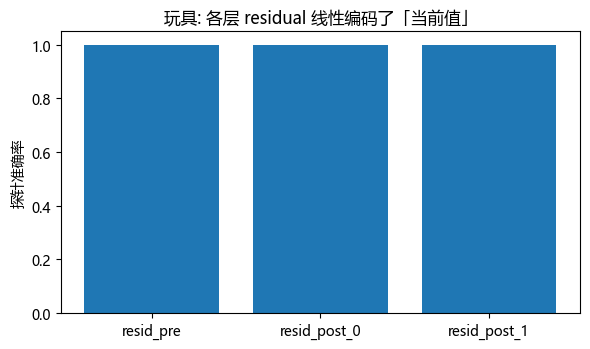

In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
torch.manual_seed(0)
Xi, Yi = tt.make_data(2000, seed=0)
model = tt.build_model(); tt.train(model, Xi, Yi, epochs=800)
Xtest, _ = tt.make_data(600, seed=5)
layers = ['resid_pre','resid_post_0','resid_post_1']; accs=[]
for key in layers:
    acts, labels = pr.tiny_layer_activations(model, Xtest, layer_key=key)
    tr, te = pr.linear_probe(acts, labels, n_classes=tt.V)
    accs.append(te); print(f'  {key:14}: 探针测试准确率 {te:.2f}')
fig,ax=plt.subplots(figsize=(6,3.6)); ax.bar(layers, accs, color='C0'); ax.set_ylim(0,1.05)
ax.set_ylabel('探针准确率'); ax.set_title('玩具: 各层 residual 线性编码了「当前值」'); plt.tight_layout(); plt.show()

## 2. 真实 gpt2: 探针读「这个 token 是不是数字」

In [3]:
tok, gpt2 = rm.gpt2()
if gpt2 is not None:
    SENTS = [
        "The year 1999 had 3 cats and 42 happy dogs.",
        "She bought 7 apples and 18 oranges yesterday.",
        "In 2024 the team scored 5 goals in 90 minutes.",
        "He read 12 books and wrote 4 long essays.",
        "The room held 256 chairs and 30 round tables.",
        "Water freezes and the bus arrives at 8 sharp.",
    ]
    LAYER = 6
    X, y = [], []
    for s in SENTS:
        ids = tok(s, return_tensors='pt')
        with torch.no_grad():
            out = gpt2(**ids, output_hidden_states=True)
        hs = out.hidden_states[LAYER][0]   # (seq, 768) 第LAYER层 residual
        for j, t in enumerate(ids.input_ids[0]):
            txt = tok.decode([t]).strip()
            X.append(hs[j].numpy()); y.append(1 if any(c.isdigit() for c in txt) else 0)
    X = np.array(X); y = np.array(y)
    print(f'gpt2 第{LAYER}层激活 {X.shape}, 数字token {y.sum()}/{len(y)}')
    tr, te = pr.linear_probe(X, y, n_classes=2, epochs=400)
    base = max(y.mean(), 1-y.mean())
    print(f'探针读「是否数字」: 测试准确率 {te:.2f} (基线={base:.2f})')
    print('→ 探针能从 gpt2 激活线性读出「是不是数字」→ 这个概念被线性编码 (一个方向)。')
else:
    print('无 gpt2, 跳过')

gpt2 第6层激活 (61, 768), 数字token 13/61
探针读「是否数字」: 测试准确率 1.00 (基线=0.79)
→ 探针能从 gpt2 激活线性读出「是不是数字」→ 这个概念被线性编码 (一个方向)。


## 3. 反思
你训了线性探针, 从玩具 + 真实 gpt2 激活读出概念。带走:
- **线性探针**: 线性分类器从激活读概念; 高准确率 = 概念被**线性编码** (一个方向)。
- 真实 gpt2 把「是不是数字」这种概念线性编码了 (探针读得出) —— feature=方向是真的。
- 探针**必须线性** (否则探针自己算概念, 不可信)。
> ⚠ 但: 探针读出 ≠ 模型在用 (相关非因果, L4)! 验证因果要靠 M12.3 干预。
下一步 N2: logit lens 看预测逐层成形。